In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout

In [39]:
df = pd.read_csv('google.csv')

In [40]:
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [41]:
df['Date'] = pd.to_datetime(df['Date'])

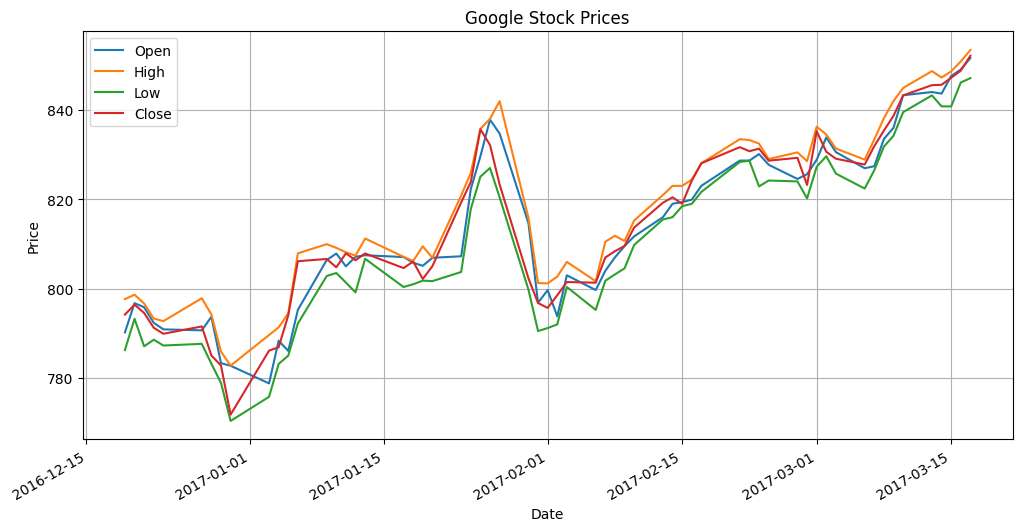

In [42]:
df.plot(x='Date',
        y=['Open','High','Low','Close'],
        figsize=(12,6))

plt.title("Google Stock Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [43]:
data = df.drop('Date',axis=1)

In [44]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [45]:
#Create Sequence
def create_sequences(data,target_col_index,seq_len=10):
    x=[]
    y=[]
    for i in range(seq_len,len(data)):
        x.append(data[i-seq_len:i])
        y.append(data[i,target_col_index])

    return np.array(x),np.array(y)
x,y = create_sequences(scaled_data,3)

In [46]:
#split dataset
split = int(len(x)*0.8)
x_train = x[:split]
y_train = y[:split]

x_test = x[split:]
y_test = y[split:]


In [47]:
model = Sequential()
model.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 790ms/step - loss: 0.2459 - val_loss: 0.3304
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.1337 - val_loss: 0.1033
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0525 - val_loss: 0.0057
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0394 - val_loss: 0.0475
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0907 - val_loss: 0.0329
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.0517 - val_loss: 0.0077
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0361 - val_loss: 0.0111
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0350 - val_loss: 0.0353
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0352 - val_loss: 0.0612
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0396 - val_loss: 0.0733
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0460 - val_loss: 0.0687
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0388 - val_lo

In [49]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


In [50]:
close_scaler = MinMaxScaler()
close_scaler.min_ = scaler.min_[3:4]
close_scaler.scale_ = scaler.scale_[3:4]
predicted_values = close_scaler.inverse_transform(y_pred)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1,1))

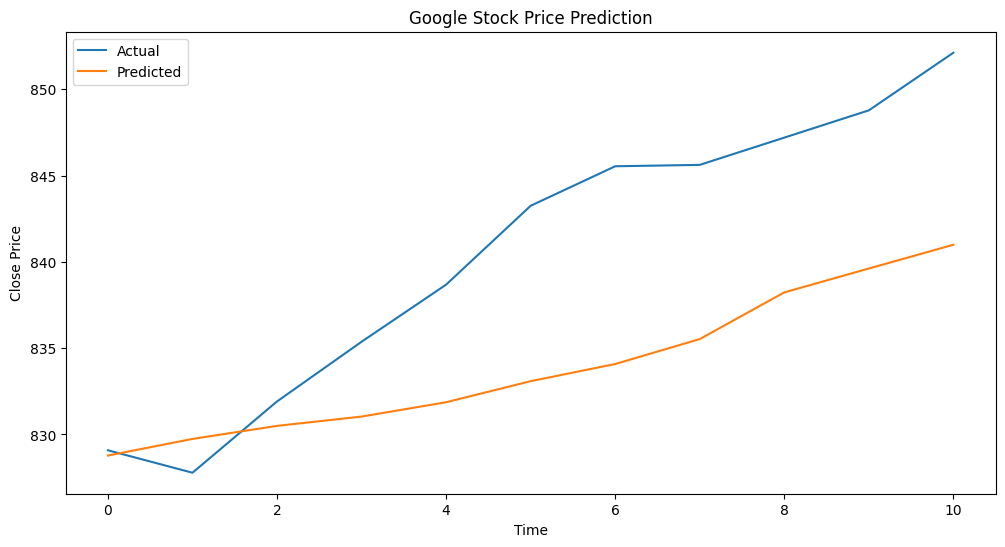

In [51]:
plt.figure(figsize=(12,6))
plt.plot(actual_values,label='Actual')
plt.plot(predicted_values,label='Predicted')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [52]:
rmse = np.sqrt(mean_squared_error(actual_values,predicted_values))
mae = mean_absolute_error(actual_values,predicted_values)
r2 = r2_score(actual_values,predicted_values)

In [53]:
print("RMSE : ",rmse)
print("MAE : ",mae)
print("R2 Score :",r2)

RMSE :  7.955152888657499
MAE :  6.892539239346589
R2 Score : 0.01016878329545401
